#  Calculation of features from available libraries

In [1]:
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

import os
import pandas as pd

dataset = 'Cr-Co-W'
from BopFoxFeaturizer.Featurizer import Featurizer

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', 'CrCoW-sorted-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
BS.dropna(inplace=True)

## Prepare Extra features

In [2]:
Features = Featurizer(BS)

In [3]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [4]:
DatasetMagneticFeature = Features.Mag
DatasetMagneticFeature = DatasetMagneticFeature.str.replace('FM','1.')
DatasetMagneticFeature = DatasetMagneticFeature.str.replace('NM','0.').astype(float)
DatasetMagneticFeature.name = 'Mag'

In [5]:
DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature), axis=1)

In [6]:
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')

In [7]:
DatasetFeatures

,Co_pv,Cr_pv,W_sv,Mag
Co_pv6W_sv6.C14-BBA.FM,0.500000,0.000000,0.500000,1.0
Co_pv6W_sv6.C14-BBA.NM,0.500000,0.000000,0.500000,0.0
Cr_pv6W_sv2.D0_19-A3B.FM,0.000000,0.750000,0.250000,1.0
Cr_pv6W_sv2.D0_19-A3B.NM,0.000000,0.750000,0.250000,0.0
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,0.133333,0.533333,0.333333,1.0
...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,0.000000,0.769231,0.230769,1.0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.066667,0.666667,0.266667,0.0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.066667,0.666667,0.266667,1.0
Co_pv13W_sv16.chi-ABAB.NM,0.448276,0.000000,0.551724,0.0


## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [8]:
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer

In [9]:
ground_states = Features.get_ground_states_energies()

In [10]:
BS['EF'] = Features.get_formation_energy(ground_states)

In [11]:
BS['EF']

Co_pv6W_sv6.C14-BBA.FM               -0.008728
Co_pv6W_sv6.C14-BBA.NM               -0.008728
Cr_pv6W_sv2.D0_19-A3B.FM              0.367659
Cr_pv6W_sv2.D0_19-A3B.NM               0.36762
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM    0.322855
                                        ...   
Cr_pv10W_sv3.mu-BAAAB.FM              0.317514
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM     0.273449
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM     0.273449
Co_pv13W_sv16.chi-ABAB.NM             0.309268
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM    0.328804
Name: EF, Length: 1681, dtype: object

In [12]:
GoodBSFile = os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl')
BS.to_pickle(GoodBSFile)

# Matminer Features 

In [13]:
from Tools.DatasetTools.GetPymatgenFeatures import *

In [14]:
descriptorslocation = os.path.join(dataset, 'Descriptors')
mmflatomic = os.path.join(descriptorslocation, 'matminer_atomic_features.pkl')
mmfdensity = os.path.join (descriptorslocation, 'matminer_density_features.pkl')
mmfcomposition =  os.path.join (descriptorslocation,'matminer_composition_features.pkl')
mmfstructure =  os.path.join (descriptorslocation,'matminer_structure_features.pkl')
mmsoapfeatures = os.path.join(descriptorslocation, 'matminer_soap_features.pkl')


BS['chemical_formula'] = get_chemical_formula(BS)

In [15]:
BS['composition'] = StrToComposition().featurize_dataframe(BS, "chemical_formula")['composition']

StrToComposition:   0%|          | 0/1681 [00:00<?, ?it/s]

In [16]:
AtomicFeaturesMagpie = load_features(mmflatomic, BS, which='atomic')
DensitiFeatures= load_features(mmfdensity, BS, which='density')
CompositionFeatures = load_features(mmfcomposition, BS, which='composition')
# SOAPFeatures = load_features(mmfstructure, BS, which='soap')
# SOAP doesnt work from matminer
# StructureFeatures = load_features(mmfstructure, BS, which='structure')

In [17]:
AtomicFeaturesMagpie.columns = AtomicFeaturesMagpie.columns.str.replace('MagpieData ','')
AtomicFeaturesMagpie.dropna(axis=1, inplace = True)
AtomicFeaturesMagpie.describe()

,minimum Number,maximum Number,range Number,mean Number,avg_dev Number,mode Number,minimum MendeleevNumber,maximum MendeleevNumber,range MendeleevNumber,mean MendeleevNumber,...,range GSmagmom,mean GSmagmom,avg_dev GSmagmom,mode GSmagmom,minimum SpaceGroupNumber,maximum SpaceGroupNumber,range SpaceGroupNumber,mean SpaceGroupNumber,avg_dev SpaceGroupNumber,mode SpaceGroupNumber
count,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.00000,1680.000000,1680.000000,1680.000000,...,1680.000000,1680.000000,1680.000000,1680.000000,1680.00000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000
mean,24.830952,67.333929,42.502976,46.656162,13.396260,47.042262,49.36369,56.851190,7.487500,52.766787,...,1.283941,0.498814,0.420856,0.466385,199.62500,228.645833,29.020833,217.725346,9.512571,217.145833
std,4.625845,16.456481,16.851840,15.816293,8.452550,24.009180,1.11056,2.634449,2.751548,2.127277,...,0.582961,0.444815,0.277723,0.710612,12.85818,3.503956,13.176636,10.054116,6.277358,16.569188
min,24.000000,24.000000,0.000000,24.000000,0.000000,24.000000,49.00000,49.000000,0.000000,49.000000,...,0.000000,0.000000,0.000000,0.000000,194.00000,194.000000,0.000000,194.000000,0.000000,194.000000
25%,24.000000,74.000000,47.000000,33.307692,5.856753,27.000000,49.00000,58.000000,7.000000,51.068966,...,1.548471,0.119113,0.181461,0.000000,194.00000,229.000000,35.000000,212.666667,4.101562,194.000000
50%,24.000000,74.000000,50.000000,44.407692,13.583829,27.000000,49.00000,58.000000,9.000000,52.166667,...,1.548471,0.387118,0.430131,0.000000,194.00000,229.000000,35.000000,220.250000,9.722222,229.000000
75%,24.000000,74.000000,50.000000,62.302885,21.555556,74.000000,49.00000,58.000000,9.000000,53.862069,...,1.548471,0.722620,0.688209,1.548471,194.00000,229.000000,35.000000,226.307692,15.555556,229.000000
max,74.000000,74.000000,50.000000,74.000000,24.793388,74.000000,58.00000,58.000000,9.000000,58.000000,...,1.548471,1.548471,0.774236,1.548471,229.00000,229.000000,35.000000,229.000000,17.500000,229.000000


In [18]:
DensitiFeatures.dropna(axis=1, inplace=True)
DensitiFeatures.describe()

,density,vpa,packing fraction
count,1680.000000,1680.000000,1.680000e+03
mean,15.310605,10.712295,1.000000e+00
std,5.073991,0.295378,2.899896e-16
min,7.511854,10.305995,1.000000e+00
25%,11.429203,10.488771,1.000000e+00
50%,14.675017,10.702010,1.000000e+00
75%,18.815359,10.939619,1.000000e+00
max,29.620964,11.494040,1.000000e+00


In [19]:
CompositionFeatures.dropna(axis=1, inplace=True)
CompositionFeatures.describe()

,HOMO_energy,LUMO_energy,gap_AO,band center,max ionic char,avg ionic char,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
count,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000
mean,-0.207622,-0.206603,0.001019,4.183921,0.091909,0.012626,2.551786,0.755090,0.713144,0.692943,0.687741,0.685108
std,0.050262,0.051105,0.005902,0.148825,0.039717,0.008048,0.555172,0.138058,0.169277,0.187401,0.192792,0.195737
min,-0.322368,-0.322368,0.000000,3.716833,0.000000,0.000000,1.000000,0.584998,0.493242,0.435713,0.416972,0.406636
25%,-0.220603,-0.220603,0.000000,4.080115,0.055973,0.004929,2.000000,0.628932,0.563224,0.530175,0.509580,0.500861
50%,-0.220603,-0.220603,0.000000,4.198989,0.115294,0.013709,3.000000,0.707107,0.673540,0.651528,0.646555,0.645325
75%,-0.181413,-0.181413,0.000000,4.298091,0.115294,0.019364,3.000000,0.897130,0.890964,0.890416,0.890411,0.890411
max,-0.118123,-0.118123,0.054052,4.397803,0.115294,0.028585,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Pyscal features 

In [20]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,'CrCoW-sorted-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [21]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)



In [22]:
PyscalFeatures

,pyscal_steinhardt_0,pyscal_steinhardt_1,pyscal_cn
Co_pv6W_sv6.C14-BBA.FM,"[0.003058067880335748, 0.003058067880335781, 0...","[0.19338053735053082, 0.19338053735053085, 0.1...","[16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12]"
Co_pv6W_sv6.C14-BBA.NM,"[0.003058067880335748, 0.003058067880335781, 0...","[0.19338053735053082, 0.19338053735053085, 0.1...","[16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12]"
Cr_pv6W_sv2.D0_19-A3B.FM,"[0.09323416294012996, 0.09323417179770714, 0.0...","[0.4832106512245095, 0.4832106384449315, 0.483...","[12, 12, 12, 12, 12, 12, 12, 12]"
Cr_pv6W_sv2.D0_19-A3B.NM,"[0.09323416294012996, 0.09323417179770714, 0.0...","[0.4832106512245095, 0.4832106384449315, 0.483...","[12, 12, 12, 12, 12, 12, 12, 12]"
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,"[0.0523612106188882, 0.05236121061888817, 0.05...","[0.4036624849492422, 0.4036624849492422, 0.403...","[14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 12, 1..."
...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,"[0.08910515349838435, 0.06417559966989618, 0.0...","[0.6472706104443742, 0.6305396060781813, 0.630...","[12, 12, 12, 12, 12, 12, 12, 15, 15, 16, 16, 1..."
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,"[0.023139325263541427, 0.02313932526354089, 0....","[0.31584518048303, 0.31584518048303006, 0.3158...","[15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 1..."
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,"[0.023139325263541427, 0.02313932526354089, 0....","[0.31584518048303, 0.31584518048303006, 0.3158...","[15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 1..."
Co_pv13W_sv16.chi-ABAB.NM,"[0.031608479261258454, 0.029443310707755178, 0...","[0.19382539926827577, 0.196998674791523, 0.196...","[16, 16, 16, 16, 16, 13, 13, 13, 13, 13, 13, 1..."


# Dataset features from CN 

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CN $$

## amount of sites in structure

In [23]:
import Tools.DatasetTools.GeneralFeaturizer as gf

In [24]:
from importlib.machinery import SourceFileLoader
gf = SourceFileLoader('gf','Tools/DatasetTools/GeneralFeaturizer.py').load_module()

In [25]:
CN = gf.featurize_series(PyscalFeatures['pyscal_cn'], PyscalFeatures.pyscal_cn, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

In [26]:
CN

,N_CN12,N_CN13,N_CN14,N_CN15,N_CN16
Co_pv6W_sv6.C14-BBA.FM,8.0,0.0,0.0,0.0,4.0
Co_pv6W_sv6.C14-BBA.NM,8.0,0.0,0.0,0.0,4.0
Cr_pv6W_sv2.D0_19-A3B.FM,8.0,0.0,0.0,0.0,0.0
Cr_pv6W_sv2.D0_19-A3B.NM,8.0,0.0,0.0,0.0,0.0
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,10.0,0.0,16.0,4.0,0.0
...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,7.0,0.0,2.0,2.0,2.0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,10.0,0.0,16.0,4.0,0.0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,10.0,0.0,16.0,4.0,0.0
Co_pv13W_sv16.chi-ABAB.NM,0.0,12.0,0.0,0.0,5.0


## Composition on CP

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [27]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'

In [28]:
CPComp = gf.featurize_series(AtomicNumbers, PyscalFeatures.pyscal_cn, return0=False)
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

In [29]:
CPComp

,Z_CN12,Z_CN13,Z_CN14,Z_CN15,Z_CN16
Co_pv6W_sv6.C14-BBA.FM,41.500000,0.000000,0.000000,0.000000,9.000000
Co_pv6W_sv6.C14-BBA.NM,41.500000,0.000000,0.000000,0.000000,9.000000
Cr_pv6W_sv2.D0_19-A3B.FM,36.500000,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,36.500000,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,11.333333,0.000000,26.133333,3.600000,0.000000
...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,12.923077,0.000000,11.384615,3.692308,7.538462
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,21.533333,0.000000,12.800000,3.200000,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,21.533333,0.000000,12.800000,3.200000,0.000000
Co_pv13W_sv16.chi-ABAB.NM,0.000000,17.655172,0.000000,0.000000,4.655172


In [30]:
DatasetFeatures = pd.concat([DatasetFeatures, CN, CPComp], axis=1)

In [31]:
DatasetFeatures.to_pickle(datasetfeatureslocation)

In [32]:
DatasetFeatures

,Co_pv,Cr_pv,W_sv,Mag,N_CN12,N_CN13,N_CN14,N_CN15,N_CN16,Z_CN12,Z_CN13,Z_CN14,Z_CN15,Z_CN16
Co_pv6W_sv6.C14-BBA.FM,0.500000,0.000000,0.500000,1.0,8.0,0.0,0.0,0.0,4.0,41.500000,0.000000,0.000000,0.000000,9.000000
Co_pv6W_sv6.C14-BBA.NM,0.500000,0.000000,0.500000,0.0,8.0,0.0,0.0,0.0,4.0,41.500000,0.000000,0.000000,0.000000,9.000000
Cr_pv6W_sv2.D0_19-A3B.FM,0.000000,0.750000,0.250000,1.0,8.0,0.0,0.0,0.0,0.0,36.500000,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,0.000000,0.750000,0.250000,0.0,8.0,0.0,0.0,0.0,0.0,36.500000,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,0.133333,0.533333,0.333333,1.0,10.0,0.0,16.0,4.0,0.0,11.333333,0.000000,26.133333,3.600000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,0.000000,0.769231,0.230769,1.0,7.0,0.0,2.0,2.0,2.0,12.923077,0.000000,11.384615,3.692308,7.538462
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.066667,0.666667,0.266667,0.0,10.0,0.0,16.0,4.0,0.0,21.533333,0.000000,12.800000,3.200000,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.066667,0.666667,0.266667,1.0,10.0,0.0,16.0,4.0,0.0,21.533333,0.000000,12.800000,3.200000,0.000000
Co_pv13W_sv16.chi-ABAB.NM,0.448276,0.000000,0.551724,0.0,0.0,12.0,0.0,0.0,5.0,0.000000,17.655172,0.000000,0.000000,4.655172


## Stainhardt parameters 

From the Steinhardt parameters obtained by Pyscal library, we also want to average over the coordination polyhedra. This time we are also saving the total average for each parameter.

$$ q_{j, CP} ^i = \dfrac{1}{n_{at}^i}\sum _{at \in CP} q_{j, at} ^i $$

In [33]:
thisFeatures = PyscalFeatures[['pyscal_steinhardt_0','pyscal_steinhardt_1']]

In [34]:
CNPyscal  = gf.featurize_many(thisFeatures, PyscalFeatures.pyscal_cn, [gf.cn_average])

  0%|          | 0/1 [00:00<?, ?it/s]

In [35]:
CNPyscal

,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN13,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN13,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Co_pv6W_sv6.C14-BBA.FM,0.021754,0.020735,0.000000,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.000000,0.064460
Co_pv6W_sv6.C14-BBA.NM,0.021754,0.020735,0.000000,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.000000,0.064460
Cr_pv6W_sv2.D0_19-A3B.FM,0.089643,0.089643,0.000000,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,0.089643,0.089643,0.000000,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,0.043541,0.036474,0.000000,0.004550,0.000248,0.002268,0.478648,0.340808,0.000000,0.061350,0.045118,0.031371
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000
Co_pv13W_sv16.chi-ABAB.NM,0.081875,0.000000,0.030092,0.000000,0.000000,0.005151,0.471315,0.000000,0.186997,0.000000,0.000000,0.033856


In [36]:
PyscalFeaturesFile = os.path.join(descriptorslocation,'CNAVPyscal.pkl')

In [37]:
CNPyscal.to_pickle(PyscalFeaturesFile)

# Characterization of Dataset Features 

In [38]:
import matplotlib.pyplot as plt

In [39]:
import seaborn as sns

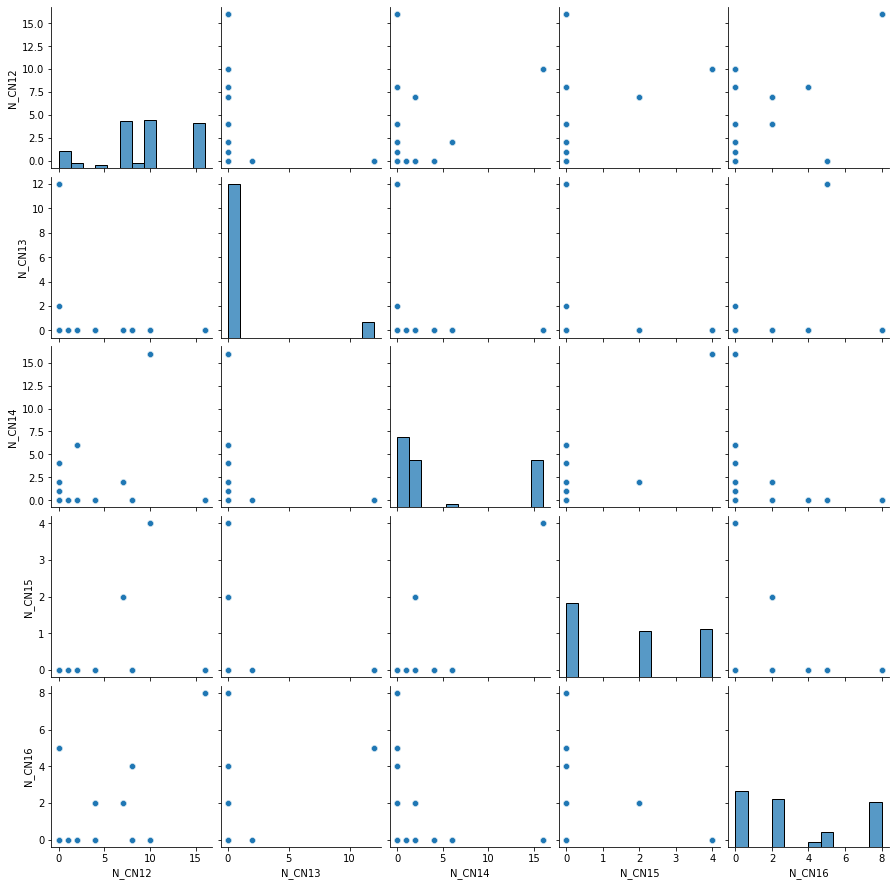

In [40]:
sns.pairplot(CN)

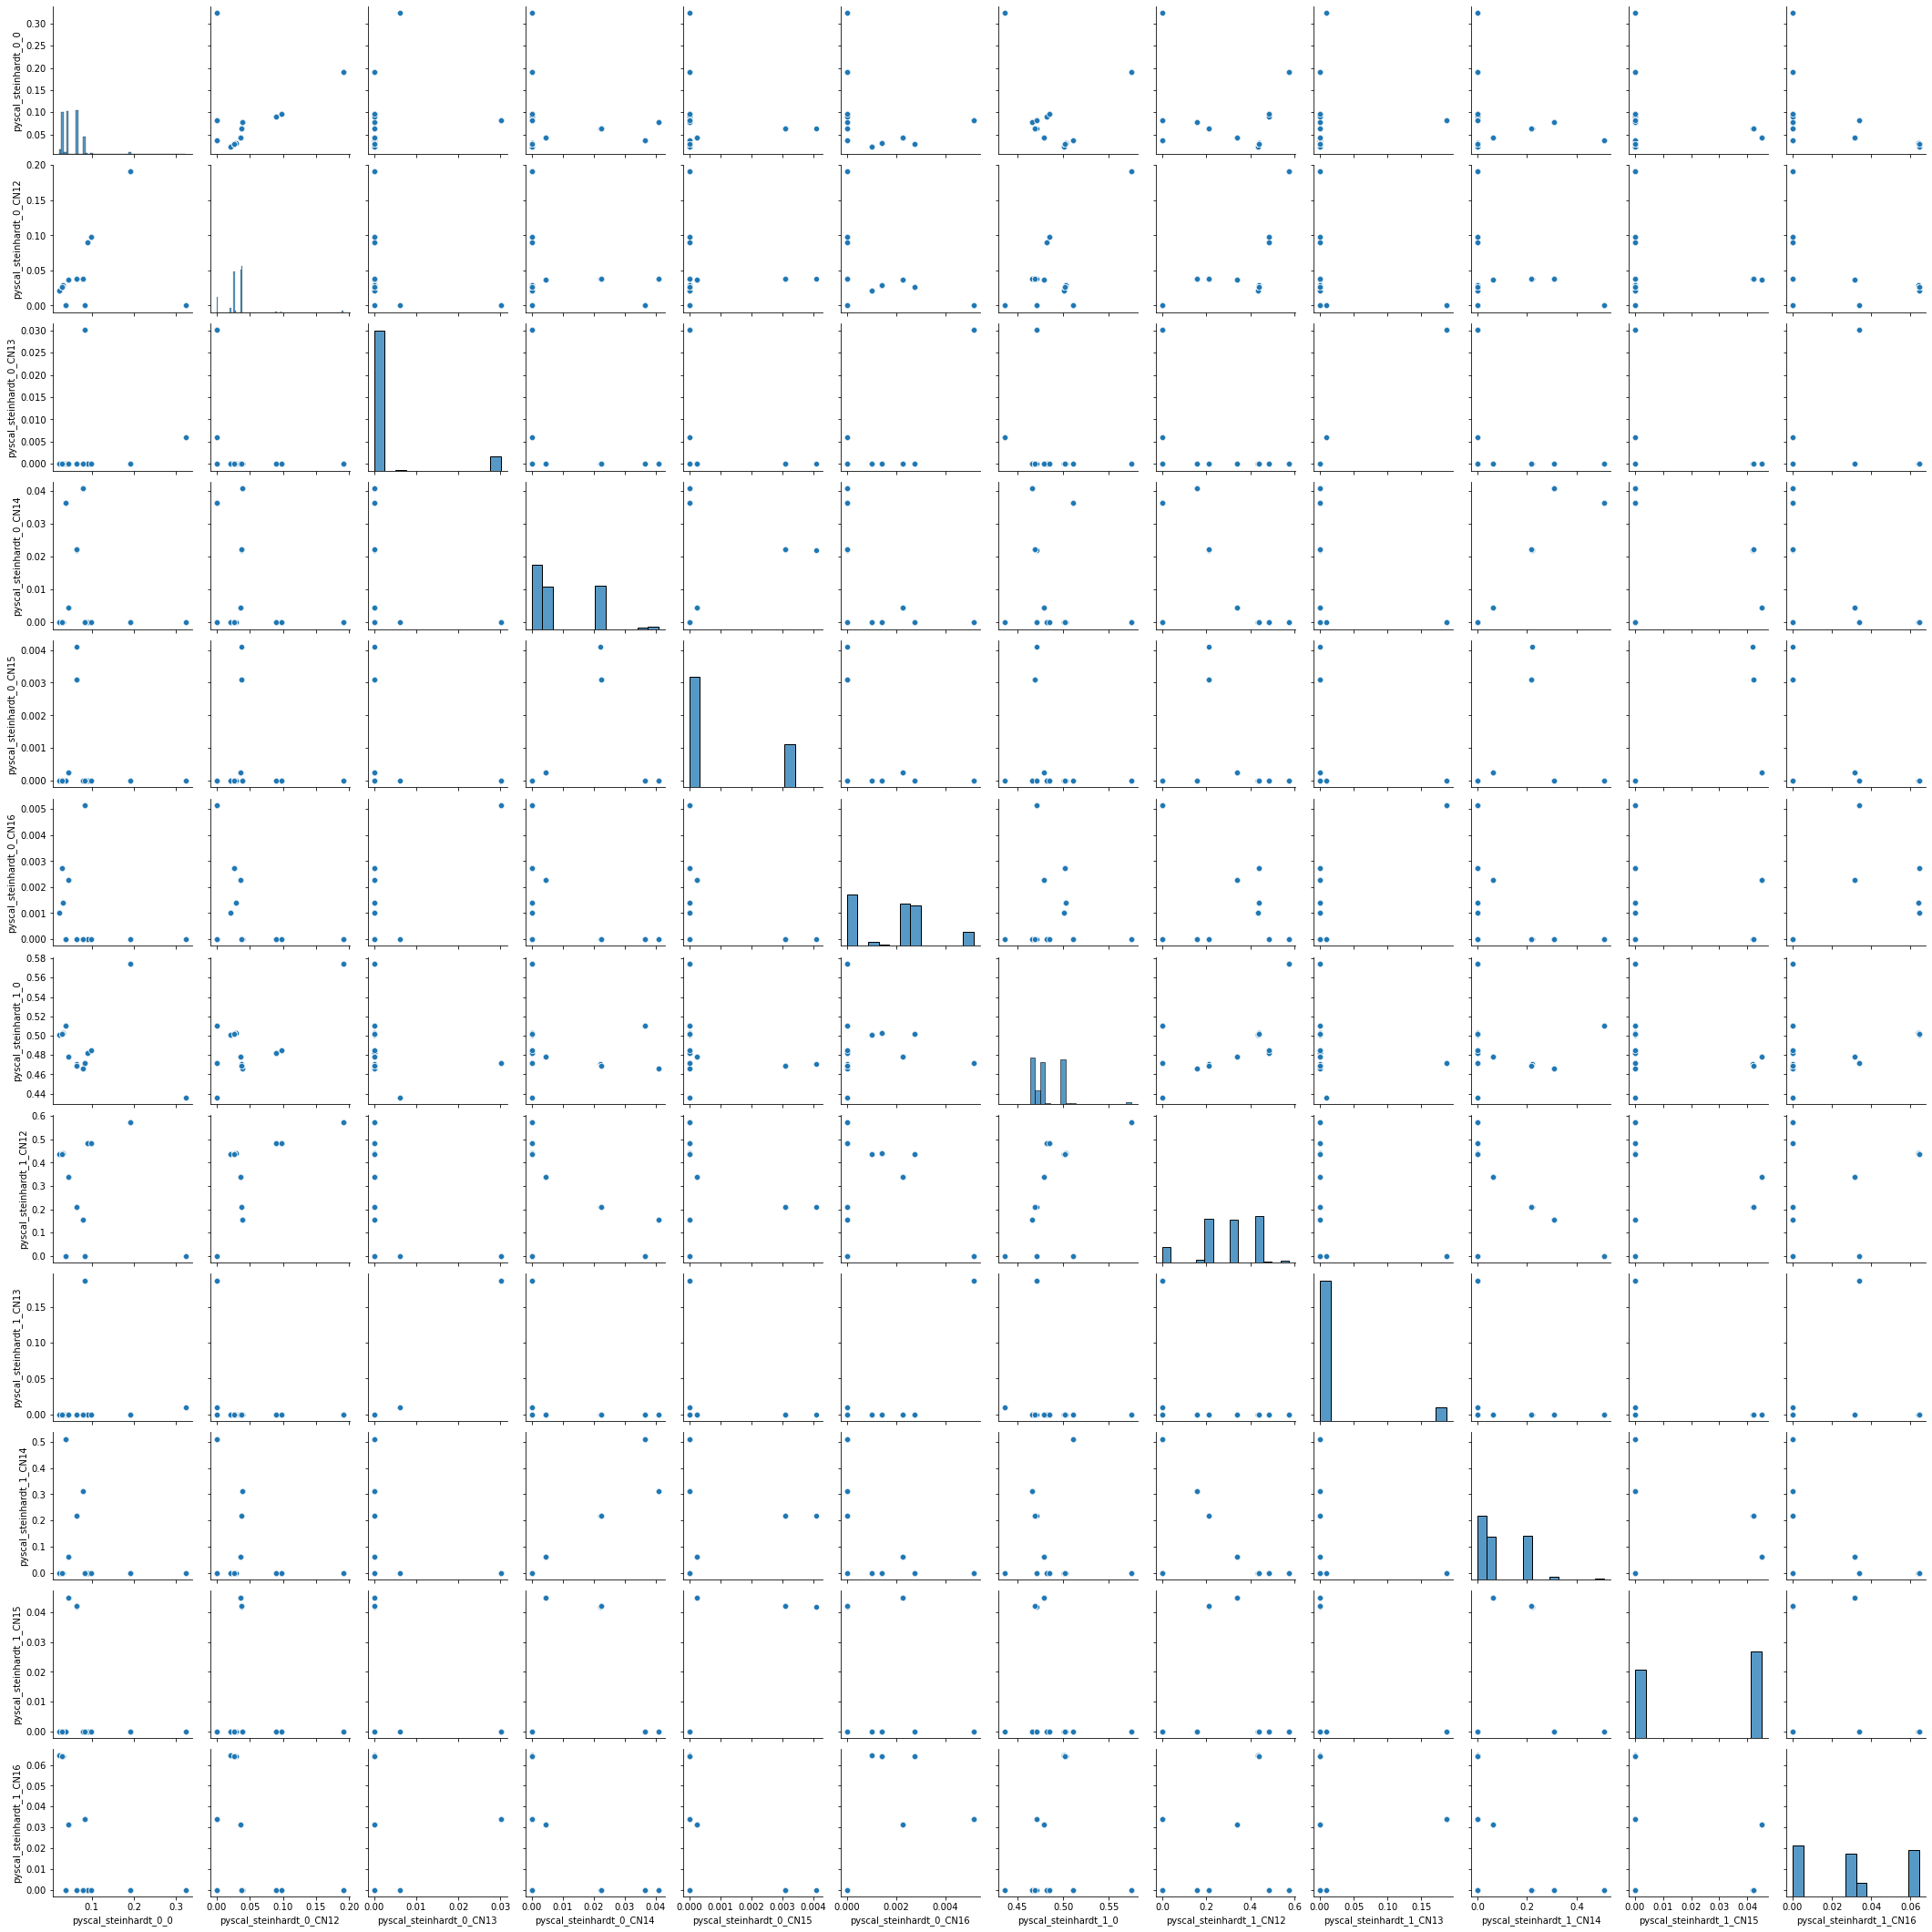

In [41]:
sns.pairplot(CNPyscal)